In [1]:
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.impute import SimpleImputer
from sklearn.ensemble import RandomForestClassifier
from xgboost import XGBClassifier
from sklearn.metrics import classification_report
import pickle
import matplotlib.pyplot as plt
import seaborn as sns

import library

In [2]:
df = pd.read_csv('Dataset_B_hotel.csv')
df['booking_status'] = df['booking_status'].map({'Canceled': 1, 'Not_Canceled': 0})
df.drop('Booking_ID', axis=1, inplace=True)
df.head()

,no_of_adults,no_of_children,no_of_weekend_nights,no_of_week_nights,type_of_meal_plan,required_car_parking_space,room_type_reserved,lead_time,arrival_year,arrival_month,arrival_date,market_segment_type,repeated_guest,no_of_previous_cancellations,no_of_previous_bookings_not_canceled,avg_price_per_room,no_of_special_requests,booking_status
0,2,0,1,2,Meal Plan 1,0.0,Room_Type 1,224,2017,10,2,Offline,0,0,0,65.00,0,0
1,2,0,2,3,Not Selected,0.0,Room_Type 1,5,2018,11,6,Online,0,0,0,106.68,1,0
2,1,0,2,1,Meal Plan 1,0.0,Room_Type 1,1,2018,2,28,Online,0,0,0,60.00,0,1
3,2,0,0,2,Meal Plan 1,0.0,Room_Type 1,211,2018,5,20,Online,0,0,0,100.00,0,1
4,2,0,1,1,Not Selected,0.0,Room_Type 1,48,2018,4,11,Online,0,0,0,94.50,0,1


membaca data, dan juga ganti tipe data dari starget dari yang bersifat tulisan canceled dan not_canceled menjadi 1 dan 0 supaya bisa di proses oleh model, drop booking id karena tidak penting dalam training

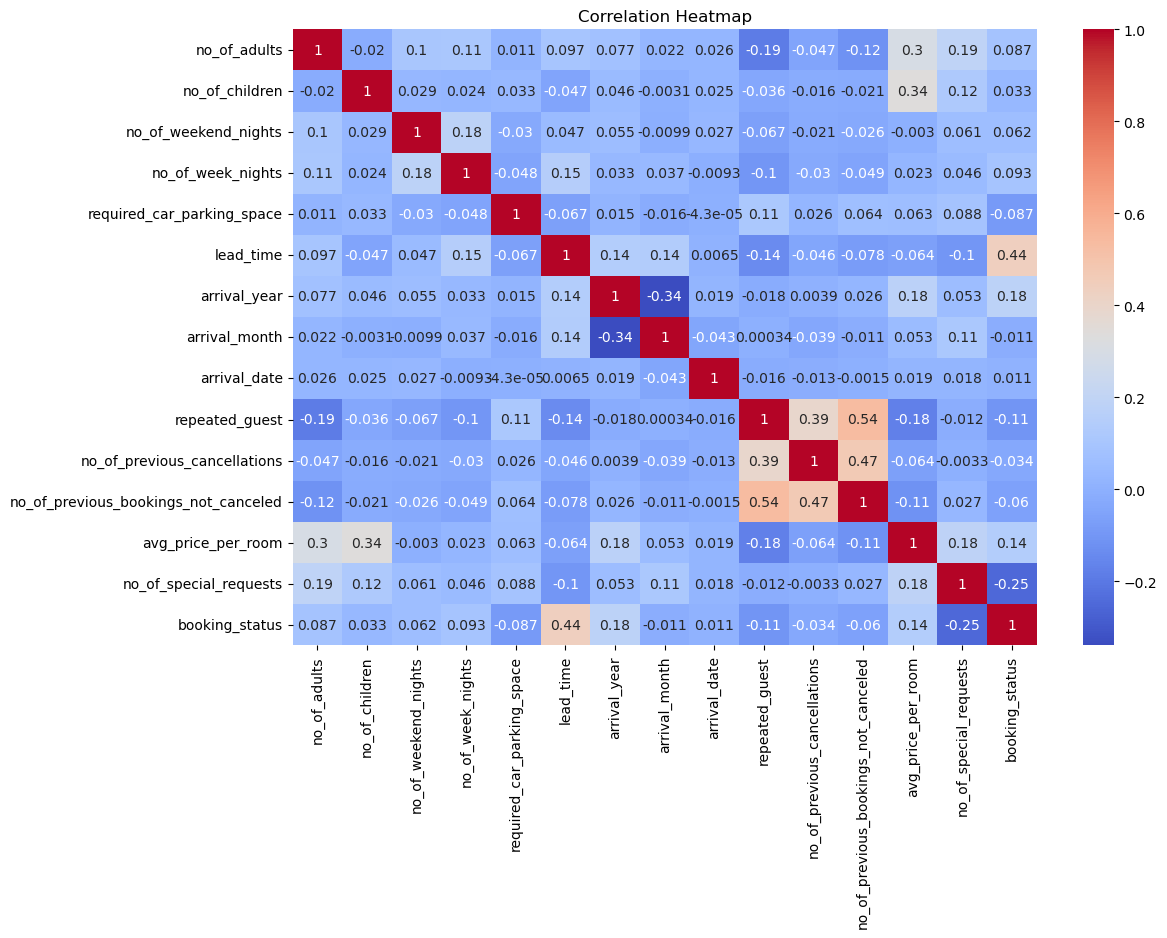

(        no_of_adults  no_of_children  no_of_weekend_nights  no_of_week_nights  \
 count   36275.000000    36275.000000          36275.000000       36275.000000   
 unique           NaN             NaN                   NaN                NaN   
 top              NaN             NaN                   NaN                NaN   
 freq             NaN             NaN                   NaN                NaN   
 mean        1.844962        0.105279              0.810724           2.204300   
 std         0.518715        0.402648              0.870644           1.410905   
 min         0.000000        0.000000              0.000000           0.000000   
 25%         2.000000        0.000000              0.000000           1.000000   
 50%         2.000000        0.000000              1.000000           2.000000   
 75%         2.000000        0.000000              2.000000           3.000000   
 max         4.000000       10.000000              7.000000          17.000000   
 
        type_o

In [3]:
summ = df.describe(include='all')

mis_val = df.isnull().sum()
plt.figure(figsize=(12, 8))
sns.heatmap(df.select_dtypes(include='number').corr(), annot=True, cmap='coolwarm')
plt.title("Correlation Heatmap")
plt.show()

summ, mis_val

dari eda yang ada di atas, kita bisa liat ada bbrp kolum yang ada missing value dan juga tmap dalam ide kasar antara korelasi antar kolum numerik

In [4]:
numer_imputer = SimpleImputer(strategy='median')
df[['required_car_parking_space', 'avg_price_per_room']] = numer_imputer.fit_transform(
    df[['required_car_parking_space', 'avg_price_per_room']])

categ_imputer = SimpleImputer(strategy='most_frequent')
df[['type_of_meal_plan']] = categ_imputer.fit_transform(df[['type_of_meal_plan']])

categ_cols = ['type_of_meal_plan', 'room_type_reserved', 'market_segment_type']
label_encoders = {}
for col in categ_cols:
    le = LabelEncoder()
    df[col] = le.fit_transform(df[col])
    label_encoders[col] = le

simpleimputer disini untuk handle missing data, terus ada encoding untuk category column

In [5]:
X = df.drop('booking_status', axis=1)
y = df['booking_status']
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=241)

buat 2 variable , yang x kita ilangin target column. yang y hanya terisi dengan target, setleah itu kami train test split untuk dataset kita 

In [6]:
rf = RandomForestClassifier(random_state=241)
rf.fit(X_train, y_train)
rf_pred = rf.predict(X_test)

xgb = XGBClassifier(use_label_encoder=False, eval_metric='logloss', random_state=241)
xgb.fit(X_train, y_train)
xgb_pred = xgb.predict(X_test)

rf_report = classification_report(y_test, rf_pred, output_dict=True)
xgb_report = classification_report(y_test, xgb_pred, output_dict=True)

d:\languages\Anaconda\Lib\site-packages\xgboost\core.py:158: UserWarning: [18:19:41] WARNING: D:\bld\xgboost-split_1737531313485\work\src\learner.cc:740: 
Parameters: { "use_label_encoder" } are not used.

  warnings.warn(smsg, UserWarning)


mentrain random forest model dan XGBClassifier

In [7]:
import pandas as pd
report = pd.DataFrame({
    'Metric': ['Precision', 'Recall', 'F1-Score'],
    'Random Forest': [rf_report['1']['precision'], rf_report['1']['recall'], rf_report['1']['f1-score']],
    'XGBoost': [xgb_report['1']['precision'], xgb_report['1']['recall'], xgb_report['1']['f1-score']]
})
report.set_index('Metric', inplace=True)
report

,Random Forest,XGBoost
Metric,,
Precision,0.887616,0.864429
Recall,0.818699,0.806098
F1-Score,0.851766,0.834245


dan dari sini kita bisa liat performa dari random forest vs XGBoost, dimana kita bisa liat secara keseluruhan score yang lebih besar diperolehi random forest walaupun perbedaannya tidak jauh

In [8]:
best_model = rf if rf_report['1']['f1-score'] > xgb_report['1']['f1-score'] else xgb
with open('best_model.pkl', 'wb') as f:
    pickle.dump(best_model, f)

gunakan kode untuk ambil model yang terbaik untuk dimasukan kedalam bentuk pickle untuk bisa dipake buat streamlit